# Banking fraud Detection Analysis using Python

## Project Goal
The purpose of this project is to analyze banking transaction data and identify patterns associated with fraudulent activity

## Tools Used


*   Python
*   pandas
*   matplotlib
*   seaborn






In [3]:
import pandas as pd

DATA_URL = 'https://raw.githubusercontent.com/danilmisterio-prog/banking-fraud-analysis/refs/heads/main/banking_transactions.csv'

bank_trans = pd.read_csv(DATA_URL)
bank_trans.head()

,transaction_id,transaction_amount,login_attempts,device_risk_score,transfer_frequency,anomaly_score,account_age_days,transaction_time_hour,failed_transactions_last_30d,avg_monthly_balance,daily_transaction_count,geo_distance_km,session_duration_minutes,transaction_velocity_score,payment_channel,authentication_type,card_present_flag,international_transaction_flag,suspicious_ip_flag,fraud_flag
0,1000001,17829.01,4,12.0,13,0.37,2354,22,25,112760.07,63,3189,92,71.8,POS Terminal,OTP,1,1,1,False
1,1000002,16401.83,1,34.3,17,0.26,3181,17,15,118899.52,83,839,63,11.8,Web Banking,Biometric,0,0,1,False
2,1000003,9678.29,8,67.8,39,0.15,1390,3,2,408168.98,9,3938,80,35.7,ATM,OTP,1,0,1,False
3,1000004,19013.38,5,17.8,42,0.55,3716,16,6,80771.69,78,11111,11,74.8,Mobile App,OTP,1,1,0,False
4,1000005,13834.95,3,88.9,63,0.24,4694,16,10,382265.32,17,3171,87,0.0,Mobile App,OTP,1,0,0,False


In [4]:
bank_trans.columns

Index(['transaction_id', 'transaction_amount', 'login_attempts',
       'device_risk_score', 'transfer_frequency', 'anomaly_score',
       'account_age_days', 'transaction_time_hour',
       'failed_transactions_last_30d', 'avg_monthly_balance',
       'daily_transaction_count', 'geo_distance_km',
       'session_duration_minutes', 'transaction_velocity_score',
       'payment_channel', 'authentication_type', 'card_present_flag',
       'international_transaction_flag', 'suspicious_ip_flag', 'fraud_flag'],
      dtype='object')

In [5]:
bank_trans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   transaction_id                  10000 non-null  int64  
 1   transaction_amount              10000 non-null  float64
 2   login_attempts                  10000 non-null  int64  
 3   device_risk_score               10000 non-null  float64
 4   transfer_frequency              10000 non-null  int64  
 5   anomaly_score                   10000 non-null  float64
 6   account_age_days                10000 non-null  int64  
 7   transaction_time_hour           10000 non-null  int64  
 8   failed_transactions_last_30d    10000 non-null  int64  
 9   avg_monthly_balance             10000 non-null  float64
 10  daily_transaction_count         10000 non-null  int64  
 11  geo_distance_km                 10000 non-null  int64  
 12  session_duration_minutes        1

In [6]:
bank_trans.describe()

,transaction_id,transaction_amount,login_attempts,device_risk_score,transfer_frequency,anomaly_score,account_age_days,transaction_time_hour,failed_transactions_last_30d,avg_monthly_balance,daily_transaction_count,geo_distance_km,session_duration_minutes,transaction_velocity_score,card_present_flag,international_transaction_flag,suspicious_ip_flag
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,1.005000e+06,12412.754004,6.438900,50.257190,39.648400,0.348916,2510.240900,11.553600,12.437800,249367.527976,60.614300,7604.567500,60.479300,50.122240,0.492800,0.498400,0.500500
std,2.886896e+03,7200.700863,3.453558,29.414463,23.419868,0.236890,1436.335019,6.962254,7.532875,144580.006647,34.821533,4330.728784,34.833419,29.271512,0.499973,0.500022,0.500025
min,1.000001e+06,6.270000,1.000000,0.000000,0.000000,0.010000,6.000000,0.000000,0.000000,104.160000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,1.002501e+06,6174.025000,3.000000,25.100000,19.000000,0.170000,1271.750000,6.000000,6.000000,122291.355000,30.750000,3896.000000,30.000000,24.800000,0.000000,0.000000,0.000000
50%,1.005000e+06,12322.965000,6.000000,50.200000,40.000000,0.310000,2511.000000,11.000000,13.000000,249799.800000,60.000000,7645.000000,61.000000,50.150000,0.000000,0.000000,1.000000
75%,1.007500e+06,18619.650000,9.000000,75.500000,60.000000,0.480000,3746.250000,18.000000,19.000000,373146.842500,91.000000,11376.250000,91.000000,75.400000,1.000000,1.000000,1.000000
max,1.010000e+06,24997.520000,12.000000,100.000000,80.000000,0.990000,5000.000000,23.000000,25.000000,499968.250000,120.000000,14997.000000,120.000000,100.000000,1.000000,1.000000,1.000000


In [7]:
bank_trans.fraud_flag.value_counts()

,count
fraud_flag,
False,8749
True,1251


In [8]:
fraud_count = bank_trans.fraud_flag.sum()
normal_count = len(bank_trans.fraud_flag) - fraud_count
frd_cnt_share = fraud_count / len(bank_trans.fraud_flag) * 100
nrm_cnt_share = normal_count / len(bank_trans.fraud_flag) * 100
fraud_stat = pd.DataFrame({'Fraud': [fraud_count, frd_cnt_share], 'Normal': [normal_count, nrm_cnt_share]}, index = ['Amount', 'Share'])
fraud_stat

,Fraud,Normal
Amount,1251.00,8749.00
Share,12.51,87.49


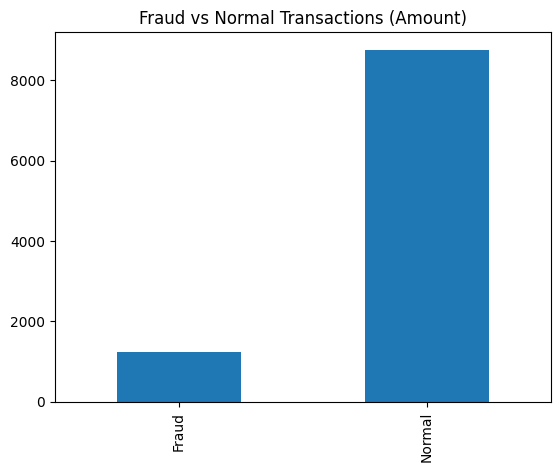

In [9]:
#CONCLUSION: A vast majority of transactions are normal, 1251 transactions (12.51%) are fraud.

import matplotlib.pyplot as plt
fraud_stat.loc['Amount'].plot(kind='bar')
plt.title('Fraud vs Normal Transactions (Amount)')
plt.show()

In [10]:
data_group = bank_trans.groupby('fraud_flag').agg({
    'transaction_amount': ['sum', 'mean', 'std'],
    'avg_monthly_balance': ['sum', 'mean', 'std']
})
data_group.columns = ['Total Transaction', 'Mean Transaction', 'Std Transaction',
    'Total Balance', 'Mean Balance', 'Std Balance']

data_group.index = ['Normal', 'Fraud']
data_group

#Turnover of transactions is 124127540, total average monthly balance is 2493675280.
#Fraud transactions value is 15657404, mean value is 12516, standard deviation is 7325. Total fraud balance is 311220360, mean fraud balance is 248777, standard deviation of fraud balance values is 145896.
#Normal transactions value is 108470135, mean value of normal transaction is 12398, standard deviation - 7183, total average balance - 2182454920, mean balance - 249451, standard deviation of balance is 144399.

#CONCLUSION: The distribution of transaction values and balance values is pretty similar to the distribution of the number of normal and fraud accounts.

,Total Transaction,Mean Transaction,Std Transaction,Total Balance,Mean Balance,Std Balance
Normal,1.084701e+08,12398.003867,7183.018614,2.182455e+09,249451.928228,144398.973169
Fraud,1.565740e+07,12515.910639,7325.254195,3.112204e+08,248777.265939,145896.617034


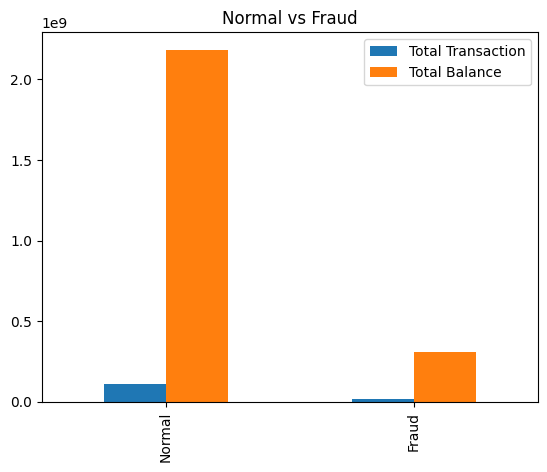

In [11]:
data_group[['Total Transaction', 'Total Balance']].plot(kind='bar')
plt.title('Normal vs Fraud')
plt.show()

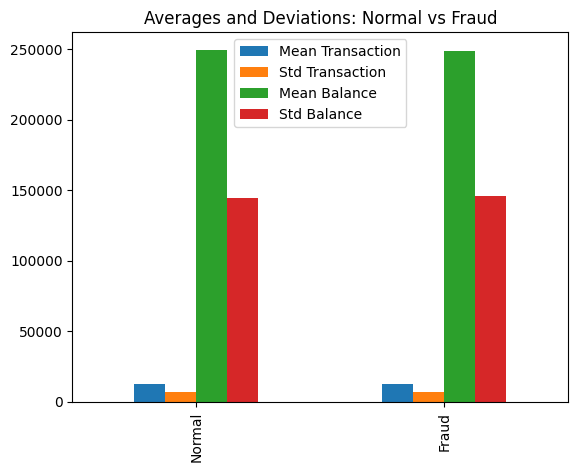

In [12]:
mean_std_cols = ['Mean Transaction', 'Std Transaction', 'Mean Balance', 'Std Balance']
data_group[mean_std_cols].plot(kind='bar')
plt.title('Averages and Deviations: Normal vs Fraud')
plt.show()

In [13]:
log_attempts = bank_trans.login_attempts.describe()
log_attempts

,login_attempts
count,10000.000000
mean,6.438900
std,3.453558
min,1.000000
25%,3.000000
50%,6.000000
75%,9.000000
max,12.000000


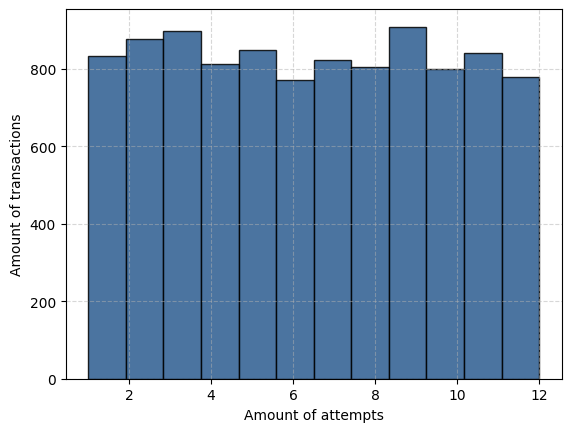

In [14]:
#CONCLUSION: The number of login attempts ranges from 1 to 12 with a mean of 6.4 ± 3.5. The distribution is wide and uniform.

bank_trans.login_attempts.hist(bins=12, edgecolor='black', color='#2b5c8f', alpha=0.85)
plt.xlabel('Amount of attempts')
plt.ylabel('Amount of transactions')
plt.grid(True, linestyle = '--', alpha = 0.5)

In [15]:
bank_trans.device_risk_score.describe()

,device_risk_score
count,10000.000000
mean,50.257190
std,29.414463
min,0.000000
25%,25.100000
50%,50.200000
75%,75.500000
max,100.000000


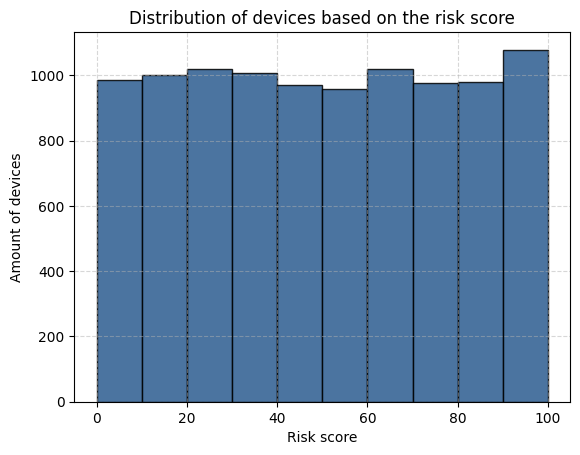

In [16]:
#CONCLUSION: Devices risk scores vary from 0 to 100 with a mean of 50.2 ± 29.4. The distribution is wide and uniform.

bank_trans.device_risk_score.hist(bins=10, edgecolor='black', color='#2b5c8f', alpha=0.85)

plt.title('Distribution of devices based on the risk score')
plt.xlabel('Risk score')
plt.ylabel('Amount of devices')
plt.grid(True, linestyle='--', alpha=0.5)

In [17]:
bank_trans.transfer_frequency.describe()

,transfer_frequency
count,10000.000000
mean,39.648400
std,23.419868
min,0.000000
25%,19.000000
50%,40.000000
75%,60.000000
max,80.000000


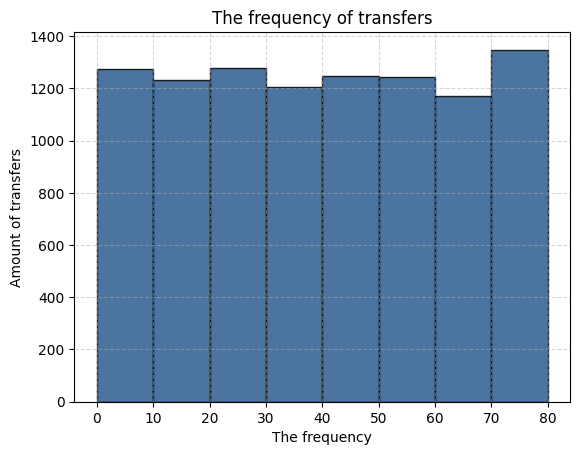

In [18]:
#CONCLUSION: The frequency of transfers vary from 0 to 100 with a mean of 39.6 ± 23.4. The distribution is wide and uniform.

bank_trans.transfer_frequency.hist(bins=8, edgecolor='black', color='#2b5c8f', alpha=0.85)

plt.title('The frequency of transfers')
plt.xlabel('The frequency')
plt.ylabel('Amount of transfers')
plt.grid(True, linestyle='--', alpha=0.5)

In [19]:
bank_trans.anomaly_score.describe()


,anomaly_score
count,10000.000000
mean,0.348916
std,0.236890
min,0.010000
25%,0.170000
50%,0.310000
75%,0.480000
max,0.990000


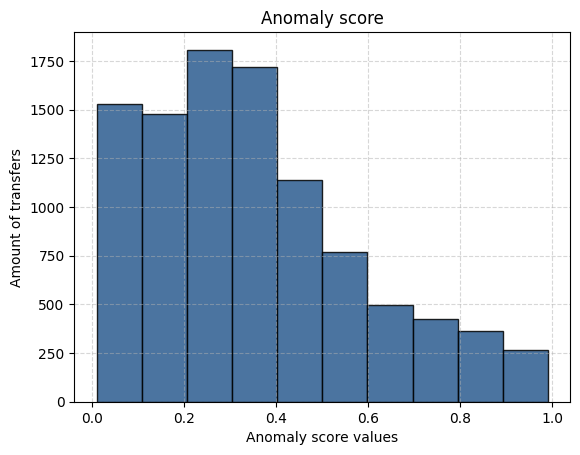

In [20]:
#CONCLUSION: The anomaly score varies from 0 to 1 with a mean of 0.35 ± 0.24. The distribution is right-skewed and non-uniform. The majority of transfers have a low anomaly score.

bank_trans.anomaly_score.hist(bins=10, edgecolor='black', color='#2b5c8f', alpha=0.85)
plt.title('Anomaly score')
plt.xlabel('Anomaly score values')
plt.ylabel('Amount of transfers')
plt.grid(True, linestyle='--', alpha=0.5)

In [21]:
bank_trans.account_age_days.describe()

,account_age_days
count,10000.000000
mean,2510.240900
std,1436.335019
min,6.000000
25%,1271.750000
50%,2511.000000
75%,3746.250000
max,5000.000000


In [22]:
bank_trans['Transactions_age_evoluation'] = bank_trans.account_age_days.map(lambda x: 'New account' if x <= 30 else 'Old account')
bank_trans['Transactions_age_evoluation'].value_counts()

,count
Transactions_age_evoluation,
Old account,9959
New account,41


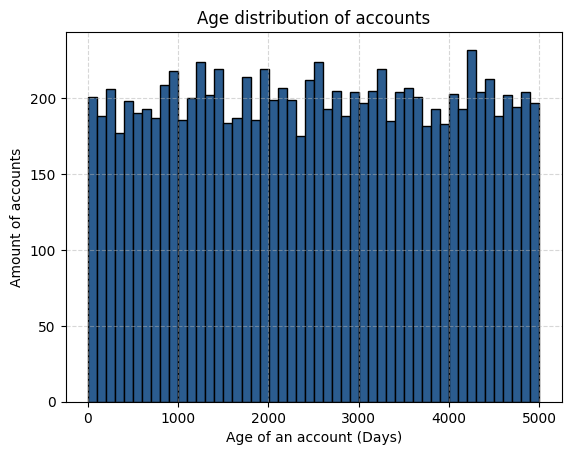

In [23]:
#CONCLUSION  Account age shows a wide and uniform distribution from 0 to 5000 days. Active transactions are heavily dominated by established accounts (99.59%), with new users contributing only 41 transactions (0.41%).

bank_trans.account_age_days.hist(bins=50, edgecolor='black', color='#2b5c8f', alpha=1)

plt.title('Age distribution of accounts')
plt.xlabel('Age of an account (Days)')
plt.ylabel('Amount of accounts')
plt.grid(True, linestyle='--', alpha=0.5)

In [24]:
bank_trans.geo_distance_km.describe()

,geo_distance_km
count,10000.000000
mean,7604.567500
std,4330.728784
min,0.000000
25%,3896.000000
50%,7645.000000
75%,11376.250000
max,14997.000000


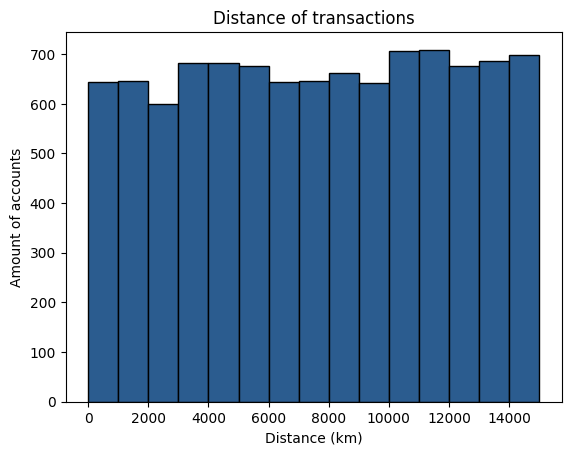

In [25]:
#CONCLUSION The transaction distance varies from 0 to approximately 15000 km with a mean of 7604.6 ± 4330.7 km. The distribution is wide and uniform, showing a high dispersion of transaction locations

bank_trans.geo_distance_km.hist(bins=15, edgecolor='black', color='#2b5c8f', alpha=1)

plt.title('Distance of transactions')
plt.xlabel('Distance (km)')
plt.ylabel('Amount of accounts')
plt.grid(True, linestyle='--', alpha=0)

In [26]:
authentication = bank_trans.authentication_type.value_counts()
authentication

,count
authentication_type,
OTP,4214
Two-Factor Authentication,2384
Password Only,1817
Biometric,1585


Text(0, 0.5, 'Amount of transactions')

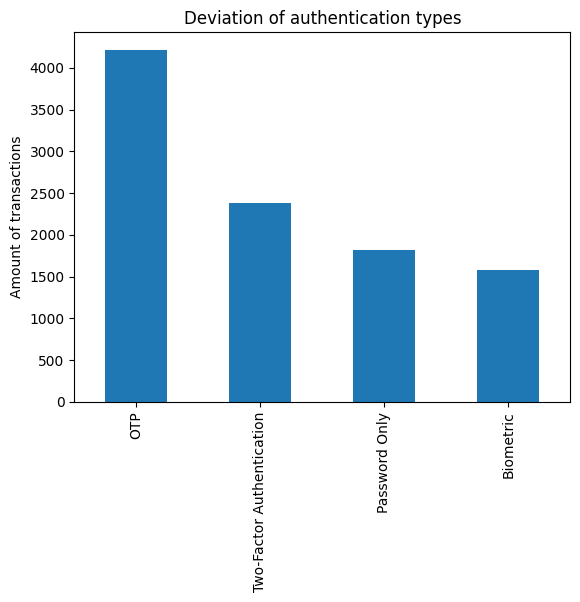

In [27]:
#CONCLUSION OTP is the most popular authentication type, accounting for over 42% of all transactions (4,214). In contrast, Biometric authentication is the least common method with only 1,585 transactions.

authentication.plot(kind='bar')
plt.title('Deviation of authentication types')
plt.xlabel('')
plt.ylabel('Amount of transactions')

In [28]:
payment_chnl = bank_trans.payment_channel.value_counts()
payment_chnl

,count
payment_channel,
Mobile App,4804
Web Banking,3247
POS Terminal,1172
ATM,777


Text(0, 0.5, 'Amount of transactions')

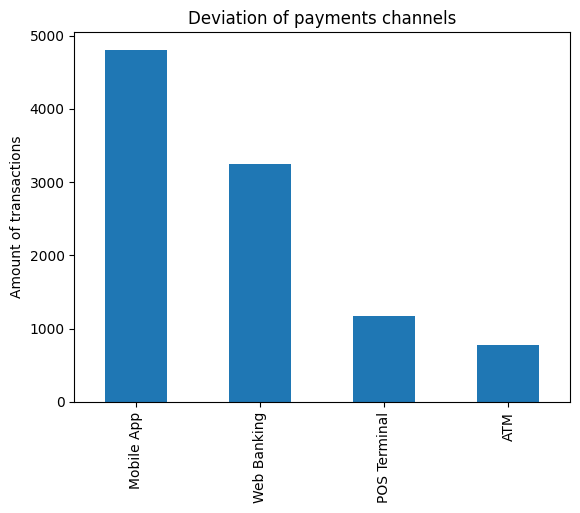

In [29]:
#CONCLUSION The Mobile App is the most popular payment channel, accounting for nearly half of all transactions (4,804). Conversely, ATM is the least utilized channel with only 777 transactions.

payment_chnl.plot(kind='bar')
plt.title('Deviation of payments channels')
plt.xlabel('')
plt.ylabel('Amount of transactions')

In [30]:
quality_of_velocity = bank_trans.transaction_velocity_score.describe()
quality_of_velocity

,transaction_velocity_score
count,10000.000000
mean,50.122240
std,29.271512
min,0.000000
25%,24.800000
50%,50.150000
75%,75.400000
max,100.000000


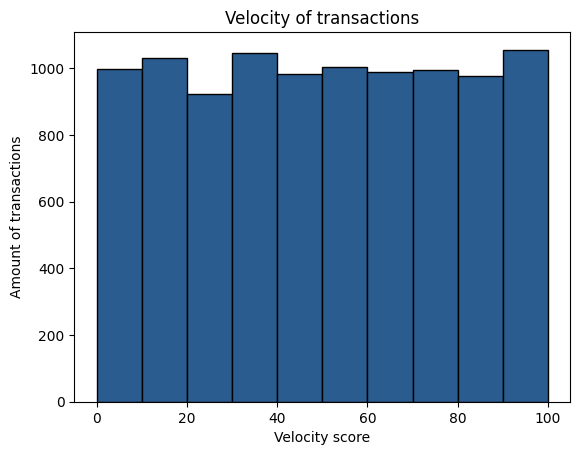

In [31]:
bank_trans.transaction_velocity_score.hist(bins=10,  edgecolor='black', color='#2b5c8f', alpha=1)

plt.title('Velocity of transactions')
plt.xlabel('Velocity score')
plt.ylabel('Amount of transactions')
#plt.xlim(0, 100)
plt.grid(True, linestyle='--', alpha=0)

#CONCLUSION: The transaction velocity score shows a wide and uniform distribution ranging from 0 to 100, with a mean of 50.1 ± 29.3. Transactions flow evenly at various steady paces without forming any distinct speed clusters.

In [32]:
bank_trans['fraud_flag'] = bank_trans['fraud_flag'].astype(bool)
corr = bank_trans.select_dtypes(include='number').corr()

corr
#CONCLUSION: Based on the correlation analysis, there is no correlation between the columns because every correlation coefficient is roughly equal to 0

,transaction_id,transaction_amount,login_attempts,device_risk_score,transfer_frequency,anomaly_score,account_age_days,transaction_time_hour,failed_transactions_last_30d,avg_monthly_balance,daily_transaction_count,geo_distance_km,session_duration_minutes,transaction_velocity_score,card_present_flag,international_transaction_flag,suspicious_ip_flag
transaction_id,1.000000,-0.007378,-0.003757,-0.008601,0.013535,-0.010033,-0.008504,-0.004304,-0.017222,0.007879,0.009662,0.012482,-0.004925,0.000568,0.006240,-0.025432,-0.003513
transaction_amount,-0.007378,1.000000,-0.001595,0.007948,-0.011134,-0.000026,-0.010839,-0.018041,-0.004773,-0.015688,-0.004291,0.000966,-0.007479,0.013551,-0.007195,-0.003678,-0.003655
login_attempts,-0.003757,-0.001595,1.000000,-0.017897,-0.019065,0.003082,0.002428,-0.003992,0.011589,0.009248,0.008822,0.005758,-0.010540,0.000479,0.000295,0.002173,-0.005484
device_risk_score,-0.008601,0.007948,-0.017897,1.000000,0.007358,0.005536,-0.004030,-0.013126,0.002800,0.008122,0.005609,0.000736,0.001284,-0.001588,0.000277,-0.012090,-0.002246
transfer_frequency,0.013535,-0.011134,-0.019065,0.007358,1.000000,-0.003774,0.009342,0.015955,-0.001191,0.010123,-0.006764,0.002743,-0.007889,0.000010,0.007881,-0.019170,0.009358
anomaly_score,-0.010033,-0.000026,0.003082,0.005536,-0.003774,1.000000,-0.009496,-0.005327,0.016186,-0.011233,-0.002879,-0.009896,-0.001880,0.007245,-0.002962,-0.000935,0.006506
account_age_days,-0.008504,-0.010839,0.002428,-0.004030,0.009342,-0.009496,1.000000,0.000171,0.007471,-0.002155,0.024294,-0.005581,0.010508,-0.013378,-0.001928,-0.007975,-0.006336
transaction_time_hour,-0.004304,-0.018041,-0.003992,-0.013126,0.015955,-0.005327,0.000171,1.000000,0.001499,-0.001696,0.001528,-0.001797,-0.012238,0.002820,0.002065,-0.004715,0.024856
failed_transactions_last_30d,-0.017222,-0.004773,0.011589,0.002800,-0.001191,0.016186,0.007471,0.001499,1.000000,-0.003086,0.010797,0.013933,-0.017541,-0.002272,0.008458,-0.005284,-0.006006
avg_monthly_balance,0.007879,-0.015688,0.009248,0.008122,0.010123,-0.011233,-0.002155,-0.001696,-0.003086,1.000000,-0.004637,0.010919,0.012516,0.007282,-0.003110,-0.002889,-0.016152


<function matplotlib.pyplot.show(close=None, block=None)>

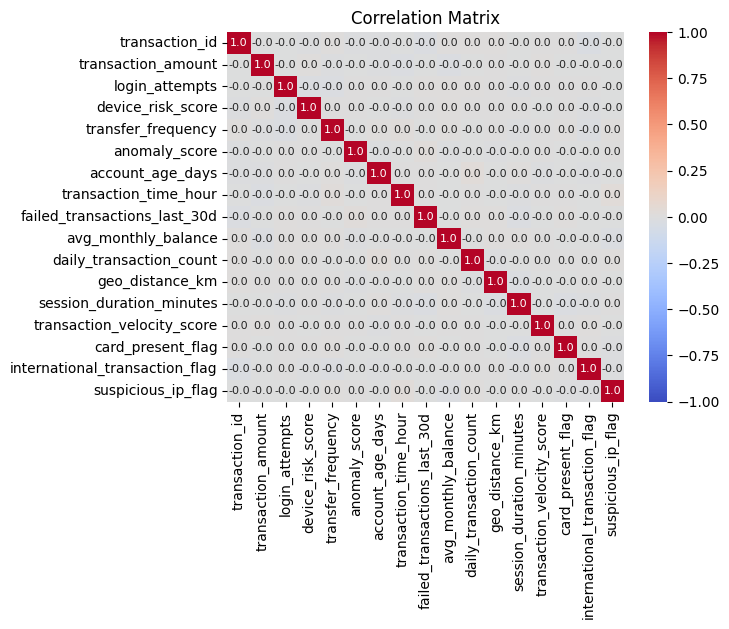

<Figure size 1400x1000 with 0 Axes>

In [33]:
import seaborn as sns
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.1f', annot_kws={"size": 8}, vmin=-1, vmax=1)

plt.title('Correlation Matrix')
plt.figure(figsize=(14, 10))

plt.show

In [34]:
columns = bank_trans.select_dtypes(include=['number']).columns.tolist()
correlation = bank_trans.groupby('fraud_flag')[columns].mean()

difference = correlation.apply(lambda x: (x.iloc[1] - x.iloc[0])/x.iloc[0], axis = 0)

difference

,0
transaction_id,-0.000039
transaction_amount,0.009510
login_attempts,-0.001570
device_risk_score,-0.002247
transfer_frequency,-0.004702
anomaly_score,1.674995
account_age_days,-0.008905
transaction_time_hour,0.000431
failed_transactions_last_30d,-0.013617
avg_monthly_balance,-0.002705


In [35]:
wide_diff = difference.idxmax()
main_factor = difference.loc[[wide_diff]]

main_factor

#CONCLUSION: The anomaly score shows the most significant relative difference between normal and fraudulent transactions. Consequently, it could be used to identify fraud transactions.

,0
anomaly_score,1.674995


# INSIGHTS:
1. Total amount of transactions is 10000, which includes 1251 (12.51%) fraud transactions and 8749 normal transactions.
2. Turnover of transactions is 124127540, total average monthly balance is 2493675280.
3. Fraud transactions value is 15657404, mean value is 12516, standard deviation is 7325. Total fraud balance is 311220360, mean fraud balance is 248777, standard deviation of fraud balance values is 145896.
4. Normal transactions value is 108470135, mean value of normal transaction is 12398, standard deviation - 7183, total average balance - 2182454920, mean balance - 249451, standard deviation of balance is 144399.
5. Users usually have from 6.4 +- 3.5 attempts to log in.
6. Devices have a wide distribution based on their risk score, mean risk score is equal to 50/100, standard deviation is 29.4.
7. Just 25% of transactions have high anomaly score (>0.48).
8. A vast majority of accounts perform 39.6 +-23.4 transactions in a month.
9. A vast majority of transactions (more than 99%) were done by old accounts and just 41 transactions (less than 1%) were performed by new customers, whose accounts have been registered during the last month.
10. The location of each transaction has wide dispersion, mean distance is equal to 7604 km +- 4330.
11. The most popular authentication type is OTP, the most unpopular - Biometric.
12. The most popular payment channel is Mobile App, the least - ATM.
13. The transaction velocity score shows a wide and uniform distribution ranging from 0 to 100, with a mean of 50.1 ± 29.3. Transactions flow evenly at various steady paces without forming any distinct speed clusters.
14. Based on the correlation analysis, there is no correlation between the columns because every correlation coefficient is roughly equal to 0
15. The anomaly score shows the most significant relative difference between normal and fraudulent transactions. Consequently, it could be used to identify fraud transactions.